<a href="https://colab.research.google.com/github/Rajugithu/focusmeet/blob/master/VGG16.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
import os
import zipfile

# Correct file name
zip_file = "EyeState.zip"

# Extract the file
with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall("EyeState")
    print("Extraction complete. Contents:")
    print(os.listdir("EyeState"))


Extraction complete. Contents:
['EyeState']


In [3]:
!pip install tensorflow keras numpy matplotlib


In [4]:
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt


In [5]:
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [6]:
for layer in base_model.layers:
    layer.trainable = False


In [ ]:
import os

# Specify the directory path
directory_path = "/content/EyeState/EyeState/Train"  # Replace with your directory path

# Check if the directory exists
if os.path.exists(directory_path):
    print(f"Directory '{directory_path}' exists.")

    # Check if the directory is accessible (readable)
    if os.access(directory_path, os.R_OK):
        print(f"Directory '{directory_path}' is accessible (readable).")
    else:
        print(f"Directory '{directory_path}' is not readable.")
else:
    print(f"Directory '{directory_path}' does not exist.")


Directory '/content/EyeState/EyeState' exists.
Directory '/content/EyeState/EyeState' is accessible (readable).


In [7]:
x = Flatten()(base_model.output)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
num_classes=8
output = Dense(num_classes, activation='softmax')(x)  # num_classes = number of categories
model = Model(inputs=base_model.input, outputs=output)


In [9]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)
val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    "/content/EyeState/EyeState/Train",
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)
val_generator = val_datagen.flow_from_directory(
    "/content/EyeState/EyeState/val",
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)
val_generator = val_datagen.flow_from_directory(
    "/content/EyeState/EyeState/Test",
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)


Found 1360 images belonging to 8 classes.
Found 80 images belonging to 8 classes.
Found 163 images belonging to 8 classes.


In [10]:
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


In [12]:
history = model.fit(
    train_generator,
    epochs=20,
    validation_data=val_generator
)


Epoch 1/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 31s 679ms/step - accuracy: 0.1520 - loss: 2.4780 - val_accuracy: 0.1227 - val_loss: 2.0761
Epoch 2/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 29s 402ms/step - accuracy: 0.1642 - loss: 2.0519 - val_accuracy: 0.1963 - val_loss: 2.0584
Epoch 3/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 21s 388ms/step - accuracy: 0.1623 - loss: 2.0610 - val_accuracy: 0.1902 - val_loss: 2.0083
Epoch 4/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 41s 387ms/step - accuracy: 0.1478 - loss: 2.0379 - val_accuracy: 0.1288 - val_loss: 2.0768
Epoch 5/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 19s 388ms/step - accuracy: 0.1648 - loss: 2.0566 - val_accuracy: 0.1902 - val_loss: 2.0105
Epoch 6/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 22s 389ms/step - accuracy: 0.1521 - loss: 2.0356 - val_accuracy: 0.2025 - val_loss: 2.0156
Epoch 7/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 41s 390ms/step - accuracy: 0.1649 - loss: 2.0180 - val_accuracy: 0.1534 - val_loss: 2.0049
Epoch 8/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 20s 401ms/step - accuracy: 0.1577 - loss: 2.0091 - val_accu

In [13]:
test_datagen = ImageDataGenerator(rescale=1./255)
test_generator = test_datagen.flow_from_directory(
    "/content/EyeState/EyeState/Test",
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

loss, accuracy = model.evaluate(test_generator)
print(f"Test Accuracy: {accuracy*100:.2f}%")


Found 163 images belonging to 8 classes.
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 111ms/step - accuracy: 0.2109 - loss: 1.9175
Test Accuracy: 22.09%


In [ ]:
#Save trained model for later user
model.save('vgg16_face_model.h5')


In [16]:
# Evaluate the model
test_loss, test_acc = model.evaluate(test_generator)

# Save metrics to a text file
with open("metrics.txt", "w") as f:
    f.write(f"Test Loss: {test_loss}\n")
    f.write(f"Test Accuracy: {test_acc}\n")

print("Metrics saved to metrics.txt")


6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 106ms/step - accuracy: 0.1920 - loss: 1.9180
Metrics saved to metrics.txt


In [17]:
import os
from shutil import copy

# Directory to save misclassified images
os.makedirs("misclassified", exist_ok=True)

# Save misclassified images
for i, (filename, true_label, predicted_label) in enumerate(zip(filenames, true_labels, predicted_classes.flatten())):
    if true_label != predicted_label:
        src_path = os.path.join("path_to_test_dataset", filename)
        dest_path = os.path.join("misclassified", f"{i}_{os.path.basename(filename)}")
        copy(src_path, dest_path)

print("Misclassified images saved to 'misclassified' directory")


FileNotFoundError: [Errno 2] No such file or directory: 'path_to_test_dataset/BottomLeft/1190.jpg'

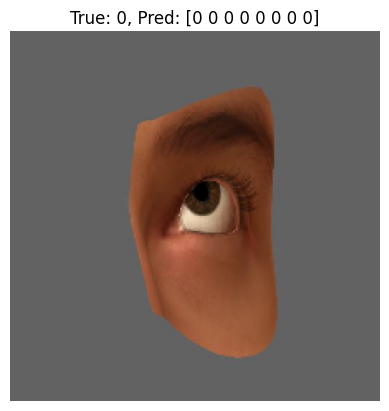

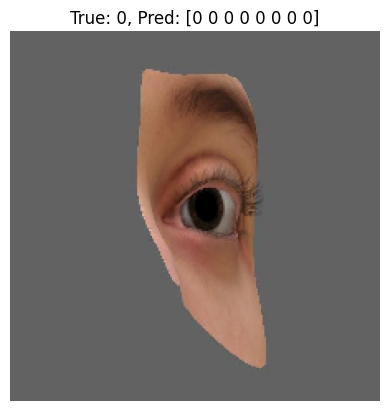

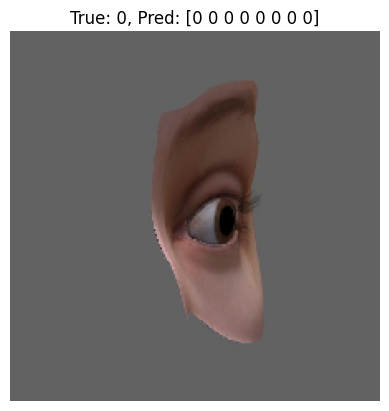

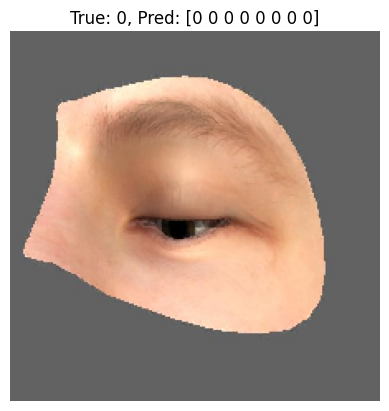

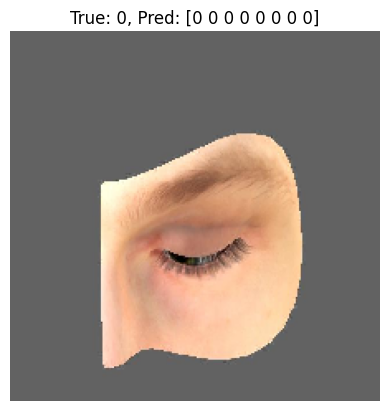

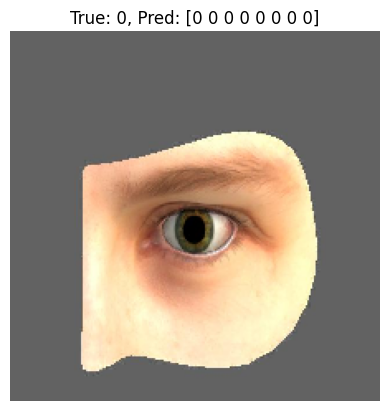

ValueError: Asked to retrieve element 6, but the Sequence has length 6

In [18]:
import matplotlib.pyplot as plt

# Plot and save some predictions
for i in range(10):  # Plot first 10 images
    img, label = test_generator[i]  # Load a batch of images
    plt.imshow(img[0])
    plt.title(f"True: {true_labels[i]}, Pred: {predicted_classes[i]}")
    plt.axis("off")
    plt.savefig(f"prediction_{i}.png")  # Save the plot
    plt.show()


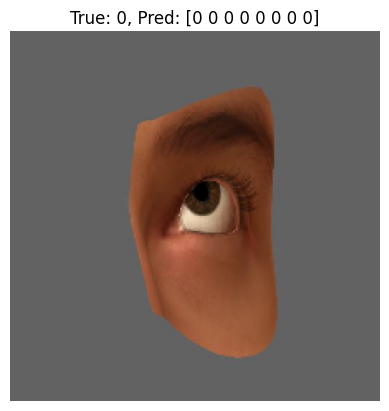

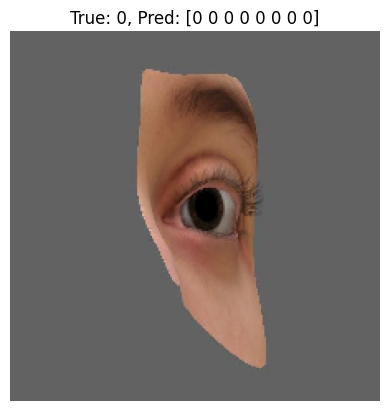

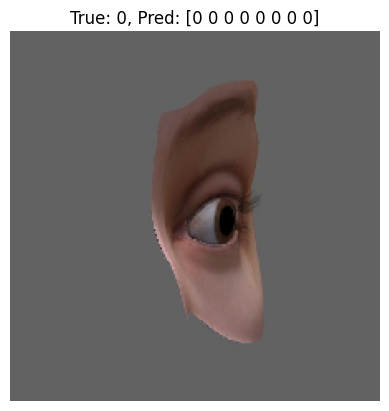

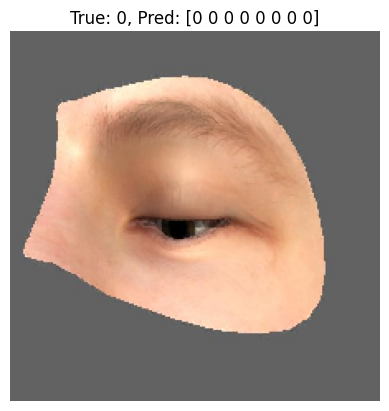

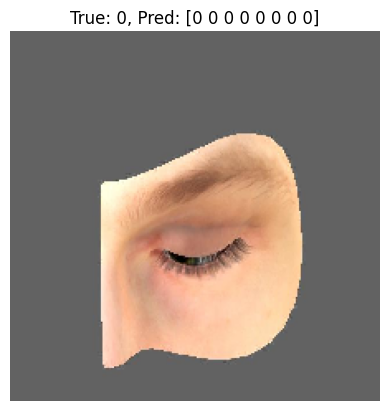

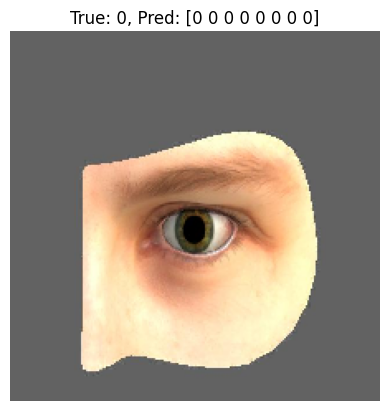

In [19]:
import matplotlib.pyplot as plt

# Calculate the total number of batches
num_batches = len(test_generator)

# Plot and save some predictions, ensuring you don't exceed available batches
for i in range(min(10, num_batches)):  # Plot up to 10 images or the total number of batches, whichever is smaller
    img, label = test_generator[i]  # Load a batch of images
    plt.imshow(img[0])
    plt.title(f"True: {true_labels[i]}, Pred: {predicted_classes[i]}")
    plt.axis("off")
    plt.savefig(f"prediction_{i}.png")  # Save the plot
    plt.show()